## 1. 머신 러닝 모델의 평가
### 1.1 `파라미터`와 `하이퍼파라미터`
- **파라미터**: 학습을 통해 업데이트되는 변수로, 가중치나 편향 등이 있음
- **하이퍼파라미터**: 학습 루프의 밖에서 주어지는 변수로, 에포크 수, 학습률 등이 있음

### 1.2 `검증 세트(Validation Set)`의 필요성
- 모델 학습의 목적은 일반화로, 훈련 과정에서 모델이 접하지 못한 새로운 데이터셋에 대해서도 예측력을 갖게 되는 것을 말함
- 따라서 모델의 성능을 검증하기 위한 `테스트 세트(Test Set)`는 `훈련 세트(Train Set)`와 분리되어야 하며, 이를 통해 모델의 `파라미터`가 `테스트 세트`에 과적합되는 것을 방지할 수 있음
- 한편, `하이퍼파라미터`는 학습 루프의 밖에서 최적화되므로, 별도의 분리된 데이터셋이 필요함

## 2. 분류(Classification)와 회귀(Regression)
### 2.1 이진 분류 문제(Binary Classification)
- 주어진 입력에 대해서 둘 중 하나의 답을 정하는 문제
- 합격/불합격, 정상/비정상 문제 등

### 2.2 다중 클래스 분류(Multi-class Classification)
- 주어진 입력에 대해서 세 개 이상의 정해진 선택지 중에서 답을 정하는 문제
- 레이블 분류 등

### 2.3 회귀 문제(Regression)
- 주어진 입력에 대해서 연속된 값을 결과로 정하는 문제
- 주가 예측, 지수 예측 등

## 3. 지도 학습(Supervised Learning)과 비지도 학습(Unsupervised Learning)
### 3.1 지도 학습
- 레이블(Label)이라는 정답과 입력값을 비교하여 오차를 줄이는 방식으로 학습

### 3.2 비지도 학습
- 레이블이 없는 학습

### 3.3 강화 학습
- 선택 가능한 행동들 중 보상을 최대화하는 행동 혹은 행동 순서를 선택하는 학습

## 4. 샘플(Sample)과 특성(Feature)
- **샘플**: 각각의 데이터 엔트리
- **특성**: 각각의 독립 변수

## 5. 혼동 행렬(Confusion Matrix)
|-|긍정|부정|
|--|--|--|
|참|TP|FN|
|거짓|FP|TN|
### 5.1 정밀도(Precision)
- 참이라고 예측한 전체 케이스에 대한 TP의 비율
$$ \text{Precision} = \frac{TP}{TP+FP} $$
### 5.2 재현률(Recall)
- 실제로 참인 전체 케이스에 대한 TP의 비율
$$ \text{Recall} = \frac{TP}{TP+FN} $$

## 6. 과적합(Overfitting)과 과소 적합(Underfitting)
- 모델 학습의 목적은 일반화로, 훈련 과정에서 모델이 접하지 못한 새로운 데이터셋에 대해서도 예측력을 갖게 되는 것을 말함
- 훈련 데이터셋에 과하게 학습될 경우, 전체 데이터에는 존재하지 않는 국소적 경향성을 학습하여 일반화 성능이 떨어질 수 있으며, 이를 `과적합(Overfitting)`이라고 함
- 반면, 훈련 데이터셋에 충분히 학습되지 않을 경우 일반화 성능의 최대값을 달성할 수 없으며, 이를 `과소적합(Underfitting)`이라고 함
- 이러한 현상은 일반적으로 아래의 그래프를 통해 확인할 수 있음

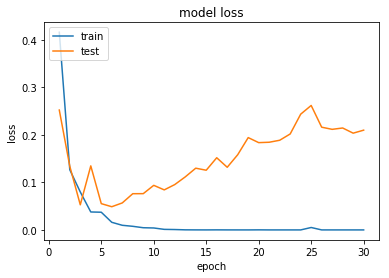

## 7. 비선형 활성화 함수
- 활성화 함수는 입력을 받아 수학적 변환을 수행하여 출력을 생성하는 함수로, 앞서 사용된 시그모이드 함수 등이 있음
- 활성화 함수로는 비선형 함수가 사용되어야 함
  - 선형 함수는 아무리 중첩하더라도 하나의 선형 함수에 아핀 변환을 가한 것과 같음
  - 따라서 선형 함수를 활용한 은닉층을 아무리 쌓더라도 수학적으로는 하나의 선형 은닉층과 같음

In [1]:
import numpy as np # 넘파이 사용
import matplotlib.pyplot as plt # 맷플롯립 사용

### 7.1 시그모이드 함수(Sigmoid function)와 기울기 소실
- 시그모이드 함수는 비선형성을 만족하나, 원점에서 멀어질수록 기울기가 줄어드는 문제가 있음
- 이는 원점에서 먼 입력값은 경사하강법을 통해 이동하기 어렵다는 것을 뜻함
- 한 번 원점에서 멀어진 입력값은 은닉층이 반복되어도 크게 변화하지 않으며, 기울기 소실로 이어짐
- 또한 시그모이드 함수는 원점 대칭이 아니므로 편향 이동(Bias shift)이 발생하기 쉬움

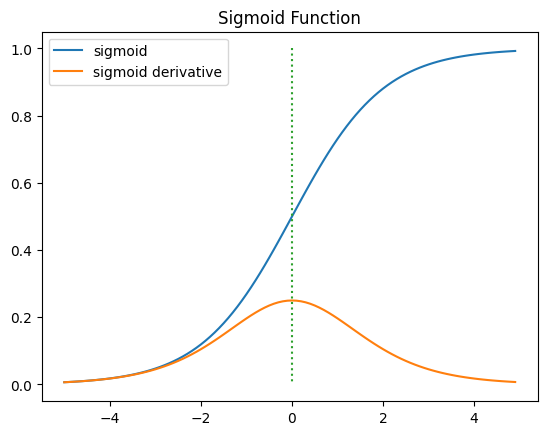

In [2]:
# 시그모이드 함수와 그 미분 함수의 그래프를 그리는 코드
def sigmoid(x):
    return 1/(1+np.exp(-x))
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))
y_derivative = sigmoid_derivative(x)

plt.plot(x, y, label='sigmoid')
plt.plot(x, y_derivative, label='sigmoid derivative')
plt.plot([0,0],[1.0,0.0], ':') # 가운데 점선 추가
plt.title('Sigmoid Function')
plt.legend()
plt.show()

### 7.2 하이퍼볼릭탄젠트 함수(Hyperbolic tangent function)
- 비선형성을 만족하며, 시그모이드 함수와 달리 원점 대칭을 이룸
- 그러나 역시 원점에서 멀어질수록 기울기가 줄어듦

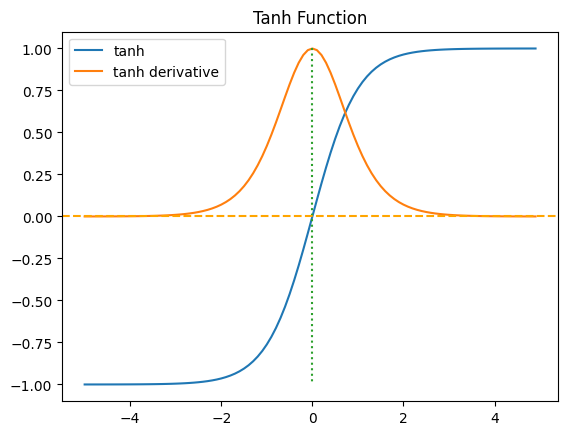

In [3]:
# Tanh 함수와 그 미분 함수의 그래프를 그리는 코드
x = np.arange(-5.0, 5.0, 0.1)
y = np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2
y_derivative = tanh_derivative(x)

plt.plot(x, y, label='tanh')
plt.plot(x, y_derivative, label='tanh derivative')
plt.plot([0,0],[1.0,-1.0], ':')
plt.axhline(y=0, color='orange', linestyle='--')
plt.title('Tanh Function')
plt.legend()
plt.show()

### 7.3 렐루 함수(ReLU)
- 비선형성을 만족하며, 양의 모든 점에서 기울기가 일정하여 감소하지 않음
- 입력값에 대해 특정한 연산을 수행하는 것이 아니라, 단순 임계값이므로 계산이 빠름
- 그러나 입력값이 음수일 경우 기울기가 0이 되어 경사하강법이 작동하지 않음 (Dying ReLu)

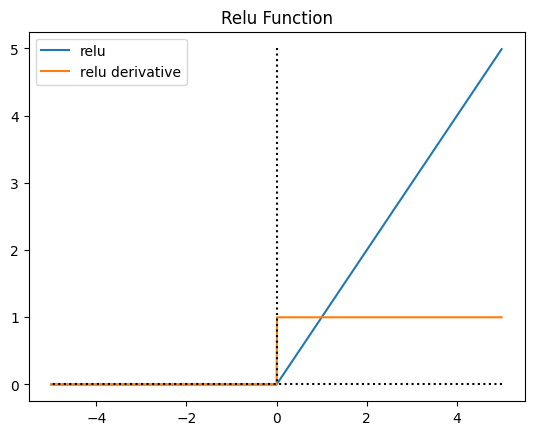

In [4]:
# ReLU 함수와 그 미분 함수의 그래프를 그리는 코드
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.01)
y = relu(x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)
y_derivative = relu_derivative(x)

plt.plot(x, y, label='relu')
plt.plot(x, y_derivative, label='relu derivative')
plt.plot([0,0],[5.0,0.0], ':', color="black")
plt.plot([5.0,-5.0],[0,0], ':', color="black")
plt.title('Relu Function')
plt.legend()
plt.show()

### 7.4 리키 렐루(Leaky ReLU)
- Dying ReLu 문제를 해결하기 위한 변형 함수 중 하나
- 음수 영역에 0이 아닌 작은 값의 기울기를 주어 문제를 해결함

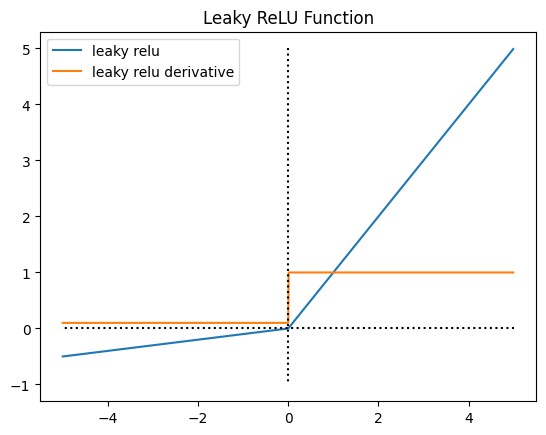

In [5]:
# Leaky ReLU 함수와 그 미분 함수의 그래프를 그리는 코드
a = 0.1

def leaky_relu(x):
    return np.maximum(a*x, x)

x = np.arange(-5.0, 5.0, 0.01)
y = leaky_relu(x)

def leaky_relu_derivative(x):
    return np.where(x > 0, 1, a)
y_derivative = leaky_relu_derivative(x)

plt.plot(x, y, label='leaky relu')
plt.plot(x, y_derivative, label='leaky relu derivative')
plt.plot([0,0],[5.0,-1.0], ':', color="black")
plt.plot([5.0,-5.0],[0,0], ':', color="black")
plt.title('Leaky ReLU Function')
plt.legend()
plt.show()

### 7.5 ELU 함수(Exponential Leaky function)
$$
\operatorname{ELU}_{\alpha}(x) = 
\begin{cases} 
    \alpha(\exp(x) - 1) & x < 0 \text{일 때} \\ 
    x & x \ge 0 \text{일 때} 
\end{cases}
$$

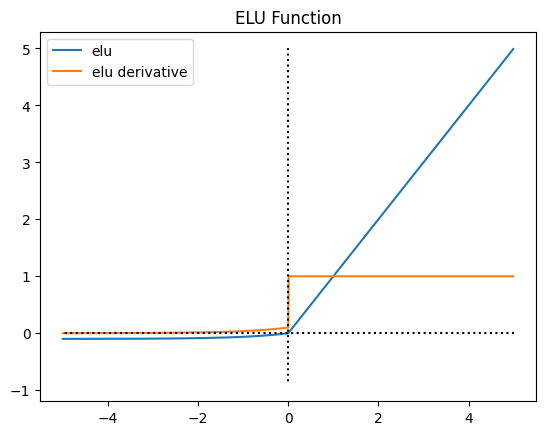

In [6]:
# ELU 함수와 그 미분 함수의 그래프를 그리는 코드
a = 0.1

def elu(x):
    return np.where(x > 0, x, a * (np.exp(x) - 1))

x = np.arange(-5.0, 5.0, 0.01)
y = elu(x)

def elu_derivative(x):
    return np.where(x > 0, 1, elu(x) + a)
y_derivative = elu_derivative(x)

plt.plot(x, y, label='elu')
plt.plot(x, y_derivative, label='elu derivative')
plt.plot([0,0],[5.0,-0.9], ':', color="black")
plt.plot([5.0,-5.0],[0,0], ':', color="black")
plt.title('ELU Function')
plt.legend()
plt.show()

### 7.6 소프트맥스 함수(Softamx function)
- 주로 출력층의 활성화 함수로 사용됨

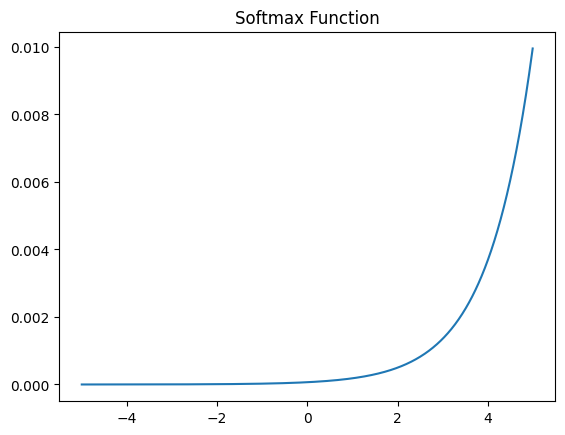

In [7]:
x = np.arange(-5.0, 5.0, 0.01)
y = np.exp(x) / np.sum(np.exp(x))

plt.plot(x, y, label='softmax')
plt.title('Softmax Function')
plt.show()

### 7.7 활성화 함수와 오차 함수의 관계
- [04-01](../04.%20Logistic%20Regression/04-01.%20logistic_regression.ipynb)에서 확인하였듯, 활성화 함수에 따라 적절한 오차 함수가 다르며, 주어진 문제에 따라 적절한 활성화 함수가 다르다

|문제|활성화 함수|비용 함수|
|--|--|--|
|이진 분류|시그모이드|nn.BCELoss()|
|다중 클래스 분류|소프트맥스|nn.CrossEntropyLoss()|
|회귀|없음|MSE|